In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import urllib.request

sns.set_theme(style="whitegrid")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
file_path = "imports-85.data"

headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
           "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

if not os.path.exists(file_path):
    print("Завантаження датасету Automobile з UCI на диск...")
    urllib.request.urlretrieve(url, file_path)
    print("Успішно збережено!")
else:
    print("Файл вже існує локально. Пропускаємо завантаження з інтернету.")

df = pd.read_csv(file_path, names=headers, na_values="?")

print(f"Датасет успішно завантажено! Розмір: {df.shape}")
display(df.head())

Файл вже існує локально. Пропускаємо завантаження з інтернету.
Датасет успішно завантажено! Розмір: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### Завдання 2: Здійснити Data Cleaning (Очищення даних)

In [2]:
df.dropna(subset=['price'], inplace=True)

numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())
    
df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

print(f"Кількість пропущених значень після очищення: {df.isnull().sum().sum()}")

Кількість пропущених значень після очищення: 0


### Завдання 3: Побудувати графік залежності одного integer/real атрибута від іншого

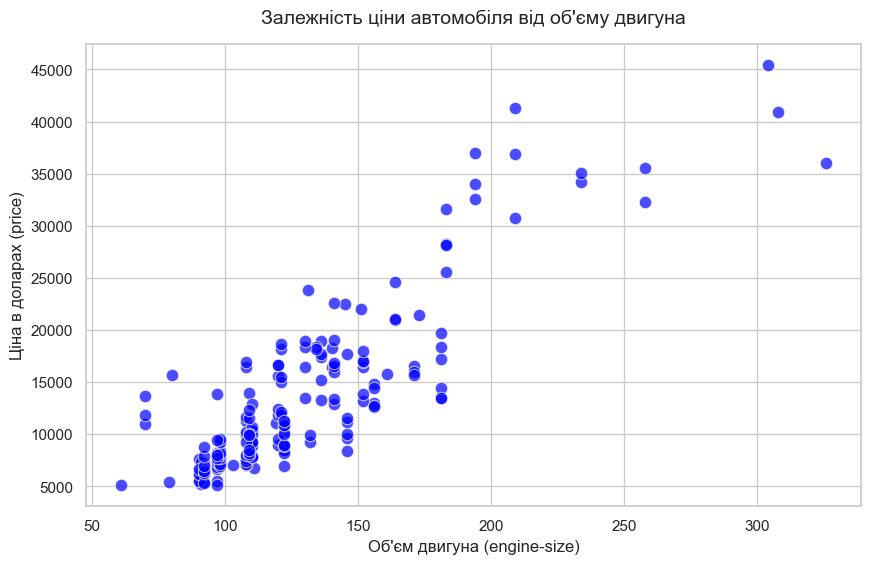

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='engine-size', y='price', alpha=0.7, color='blue', s=80)

plt.title("Залежність ціни автомобіля від об'єму двигуна", fontsize=14, pad=15)
plt.xlabel("Об'єм двигуна (engine-size)", fontsize=12)
plt.ylabel("Ціна в доларах (price)", fontsize=12)
plt.show()

### Завдання 4: Побудувати гістограму по одному з атрибутів на 5 діапазонів

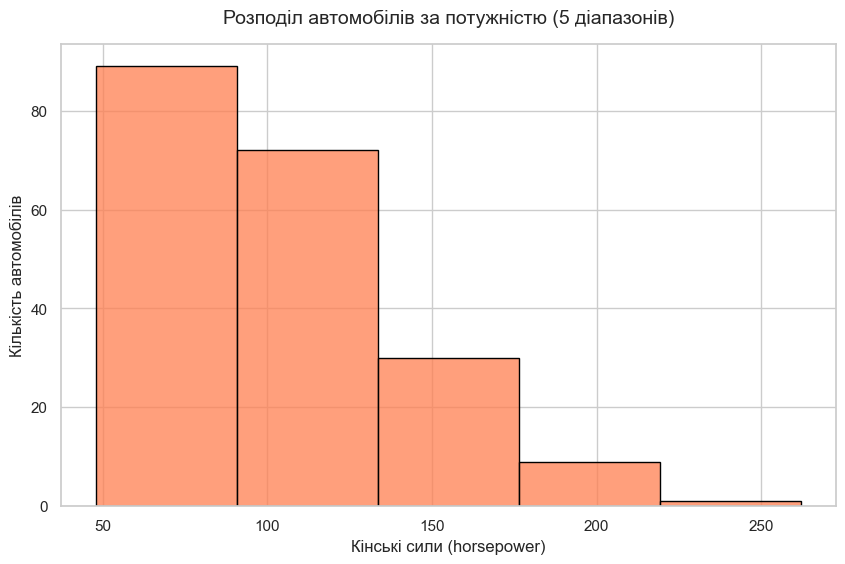

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='horsepower', bins=5, color='coral', edgecolor='black')

plt.title("Розподіл автомобілів за потужністю (5 діапазонів)", fontsize=14, pad=15)
plt.xlabel("Кінські сили (horsepower)", fontsize=12)
plt.ylabel("Кількість автомобілів", fontsize=12)
plt.show()

### Завдання 5 та 6: Багатовимірні візуалізації та додаткові графіки про датасет (загальна кількість 6)

/var/folders/p3/wtgz6zlj68j86qg9mjs_1w600000gn/T/ipykernel_16561/2313226770.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='body-style', y='price', palette='Set2')


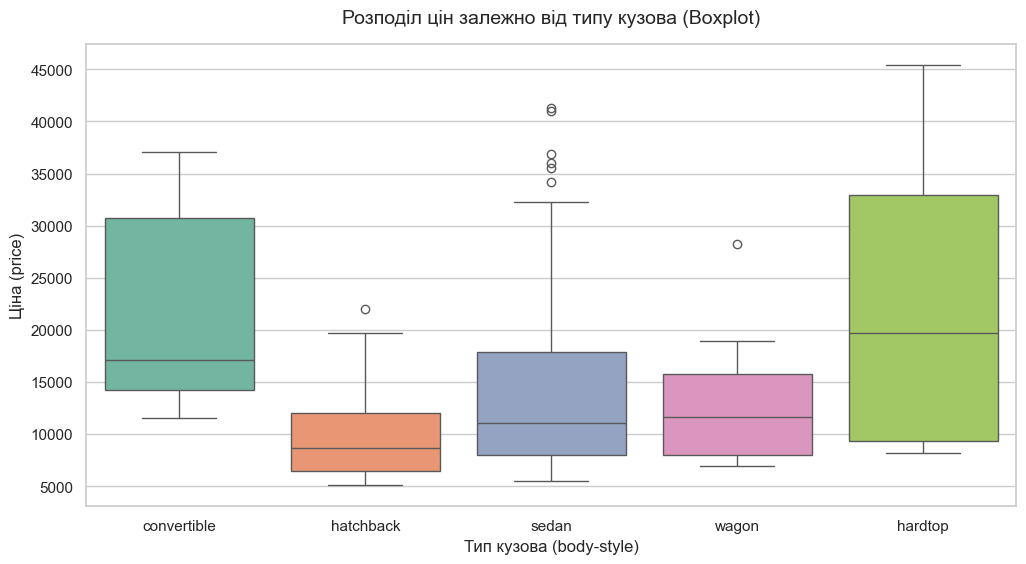

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='body-style', y='price', palette='Set2')

plt.title("Розподіл цін залежно від типу кузова (Boxplot)", fontsize=14, pad=15)
plt.xlabel("Тип кузова (body-style)", fontsize=12)
plt.ylabel("Ціна (price)", fontsize=12)
plt.show()

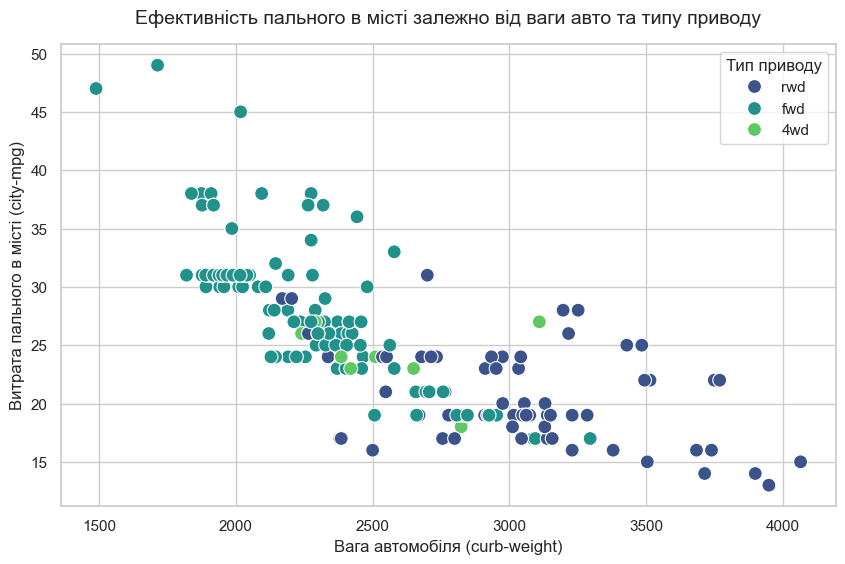

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='curb-weight', y='city-mpg', hue='drive-wheels', palette='viridis', s=100)

plt.title("Ефективність пального в місті залежно від ваги авто та типу приводу", fontsize=14, pad=15)
plt.xlabel("Вага автомобіля (curb-weight)", fontsize=12)
plt.ylabel("Витрата пального в місті (city-mpg)", fontsize=12)
plt.legend(title='Тип приводу')
plt.show()

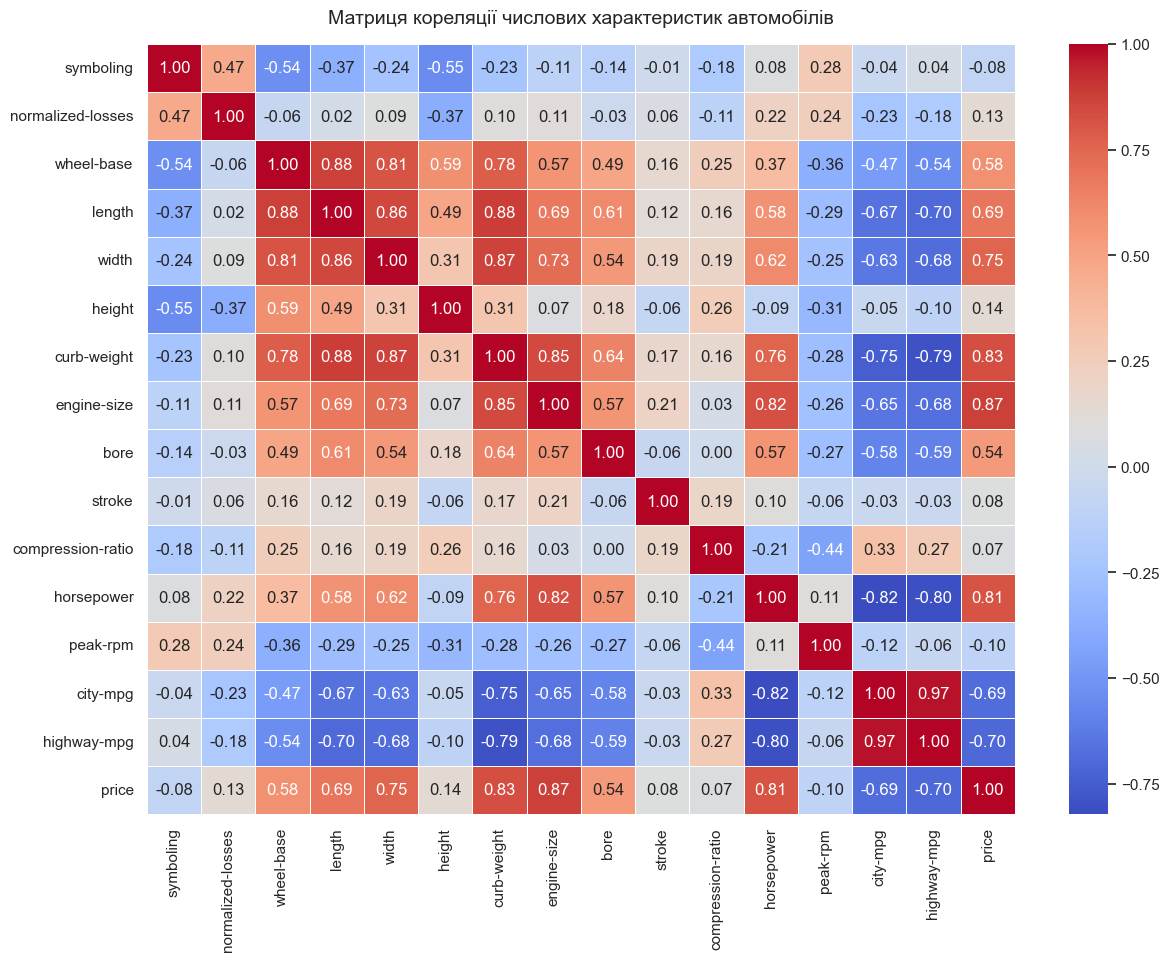

In [7]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Матриця кореляції числових характеристик автомобілів", fontsize=14, pad=15)
plt.show()

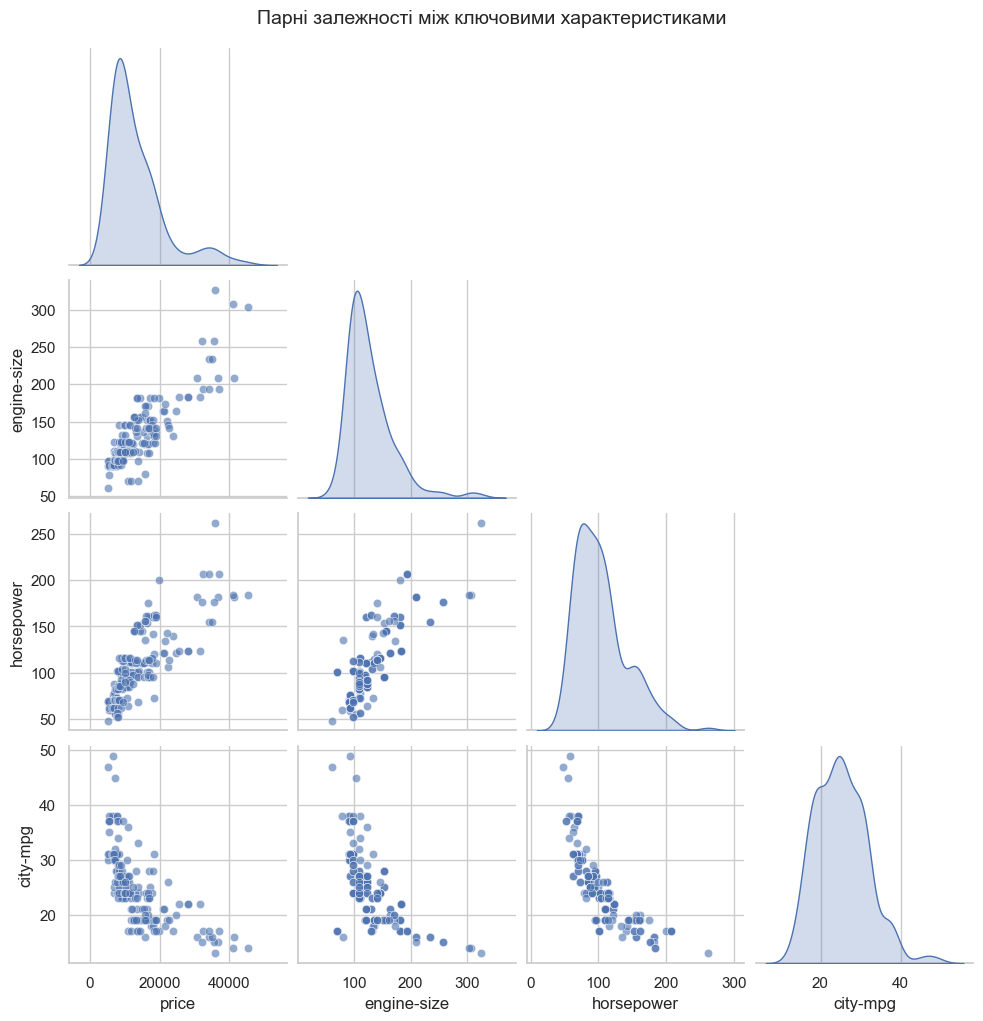

In [8]:
subset_cols = ['price', 'engine-size', 'horsepower', 'city-mpg']

sns.pairplot(df[subset_cols], diag_kind='kde', corner=True, plot_kws={'alpha':0.6})
plt.suptitle("Парні залежності між ключовими характеристиками", y=1.02, fontsize=14)
plt.show()